# kMate founder-frequency fix — results

**Problem.** kMate global-mode EM drove ~tens of the 231 equimolar seed-mix founders to ~0, biasing every p0-anchored selection coefficient.

**Root cause.** The EM M-step normalizes each iteration by a *global* count total instead of each founder's own k-mer content `Kf_w`. At the fixed point it converges to `hat_h_f ∝ h_true_f · Kf_w_f` — k-mer-rich (cactus/long-read) founders over-credited, k-mer-poor founders collapse.

**Fix (`normalize="per_founder"`).** Divide the M-step by each founder's own `Kf_w` and renormalize — the RNA-seq effective-length correction (RSEM: `tau_i = (theta_i/l_i)/sum_j(theta_j/l_j)`), which the old EM omitted.

This notebook shows **h estimate vs truth** and **AF estimate vs truth**, plus the supporting factorial.

In [1]:
%matplotlib inline
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.sparse as sp
plt.rcParams.update({'figure.dpi':110,'font.size':10})
ROOT="/global/scratch/users/tbellg/kmate"
SV=f"{ROOT}/analysis/grenenet_selection/qc/seedmix_validation"
U=1/231
PROD_KEY="h__FILT2INV|multinomial|1/mb"
FIX_KEY ="h__FILT2INV|poisson|none"
WATCH=["9977","9985","10013","9941","9507","9761"]

abl=np.load(f"{SV}/fix_ablation/ablation_h.npz",allow_pickle=True)
fo=abl['founders'].astype(str); F=len(fo)
h_truth_g0=abl['h_truth']
h_prod_g0=abl[PROD_KEY]; h_fix_g0=abl[FIX_KEY]
print("founders",F,"| g0 truth range",h_truth_g0.min(),h_truth_g0.max())

founders 231 | g0 truth range 0.004329004329004329 0.004329004329004329


## 1. h estimate vs truth — skewed-truth simulation (planted selection)

Truth = 20 founders elevated 6x (a synthetic selection signal). This tests that the fix recovers *real* frequency differences. `y = x` is perfect; slope < 1 = the estimator compresses real differences; points on the x-axis = collapsed founders.

pearson(fix,truth)=1.000  pearson(prod,truth)=0.546


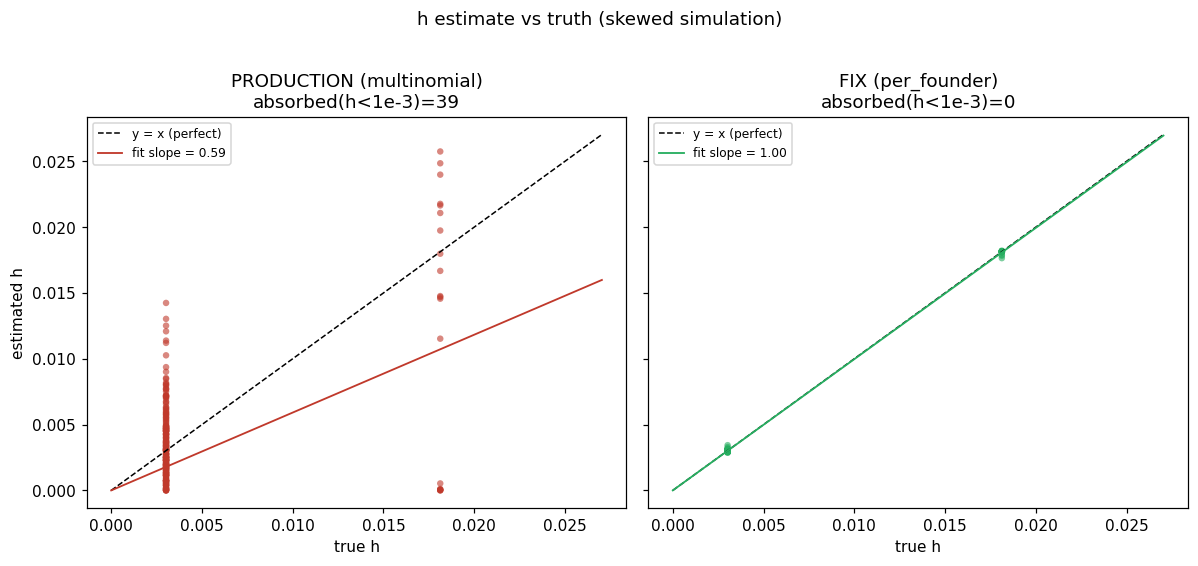

In [2]:
rn=np.load(f"{SV}/fix_norm/results_h.npz",allow_pickle=True)
rng=np.random.default_rng(0); fol=list(fo)
collapsers=[fol.index(w) for w in WATCH if w in fol]
others=rng.choice([i for i in range(F) if i not in collapsers],20-len(collapsers),replace=False)
hi=np.array(sorted(set(collapsers)|set(others.tolist())))
h_skew=np.full(F,1.0); h_skew[hi]=6.0; h_skew/=h_skew.sum()
hp=rn["h__PROD_skew_noisy_multinomial_1/mb"]
hf=rn["h__PROD_skew_noisy_poisson_None"]
def slope(est,tru):
    A=np.vstack([tru,np.ones_like(tru)]).T; return np.linalg.lstsq(A,est,rcond=None)[0][0]
print("pearson(fix,truth)=%.3f  pearson(prod,truth)=%.3f"%(
      np.corrcoef(hf,h_skew)[0,1],np.corrcoef(hp,h_skew)[0,1]))

fig,ax=plt.subplots(1,2,figsize=(11,5),sharex=True,sharey=True)
lim=(0,max(h_skew.max(),hp.max(),hf.max())*1.05)
for a,(est,lab,col) in zip(ax,[(hp,"PRODUCTION (multinomial)","#c0392b"),(hf,"FIX (per_founder)","#27ae60")]):
    a.scatter(h_skew,est,s=18,alpha=0.6,color=col,edgecolor='none')
    a.plot(lim,lim,'k--',lw=1,label='y = x (perfect)')
    s=slope(est,h_skew); xs=np.linspace(*lim,10); a.plot(xs,s*xs,color=col,lw=1.2,label=f'fit slope = {s:.2f}')
    a.set_title(f"{lab}\nabsorbed(h<1e-3)={int((est<1e-3).sum())}")
    a.set_xlabel("true h"); a.legend(loc='upper left',fontsize=8)
ax[0].set_ylabel("estimated h")
fig.suptitle("h estimate vs truth (skewed simulation)",y=1.02); fig.tight_layout(); plt.show()

**Read:** production points fall on a shallow line (slope ~0.6) with many founders crushed onto the x-axis (collapsed). The fix sits on `y=x` (slope ~1.0) with zero collapse — real selection differences preserved.

## 2. h estimate vs truth — equimolar seed-mix simulation (g0, all founders = 1/231)

Truth is uniform (`1/231`, dashed). Production drops many founders far below the line (to ~1e-15); the fix keeps every founder on it.

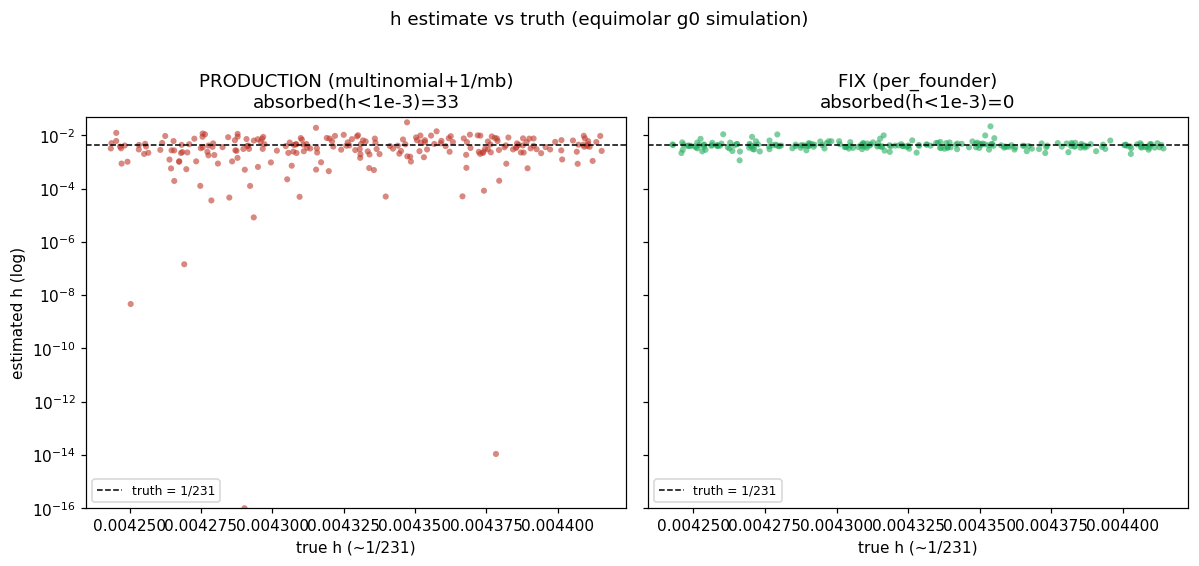

In [3]:
fig,ax=plt.subplots(1,2,figsize=(11,5),sharey=True)
rngj=np.random.default_rng(1)
for a,(est,lab,col) in zip(ax,[(h_prod_g0,"PRODUCTION (multinomial+1/mb)","#c0392b"),
                               (h_fix_g0,"FIX (per_founder)","#27ae60")]):
    xj=h_truth_g0*(1+rngj.uniform(-0.02,0.02,F))
    a.scatter(xj,np.maximum(est,1e-16),s=16,alpha=0.6,color=col,edgecolor='none')
    a.axhline(U,color='k',ls='--',lw=1,label='truth = 1/231')
    a.set_yscale('log'); a.set_ylim(1e-16,0.05)
    a.set_title(f"{lab}\nabsorbed(h<1e-3)={int((est<1e-3).sum())}")
    a.set_xlabel("true h (~1/231)"); a.legend(fontsize=8)
ax[0].set_ylabel("estimated h (log)")
fig.suptitle("h estimate vs truth (equimolar g0 simulation)",y=1.02); fig.tight_layout(); plt.show()

## 3. AF estimate vs truth — per-record allele frequency (the deliverable)

Project each founder mixture `h` through arch3 `var_pa` (`(h·var_pa)/(h·var_called)`) and compare to the simulation per-record truth AF.

AF-MAE  production=0.0096  fix=0.0036


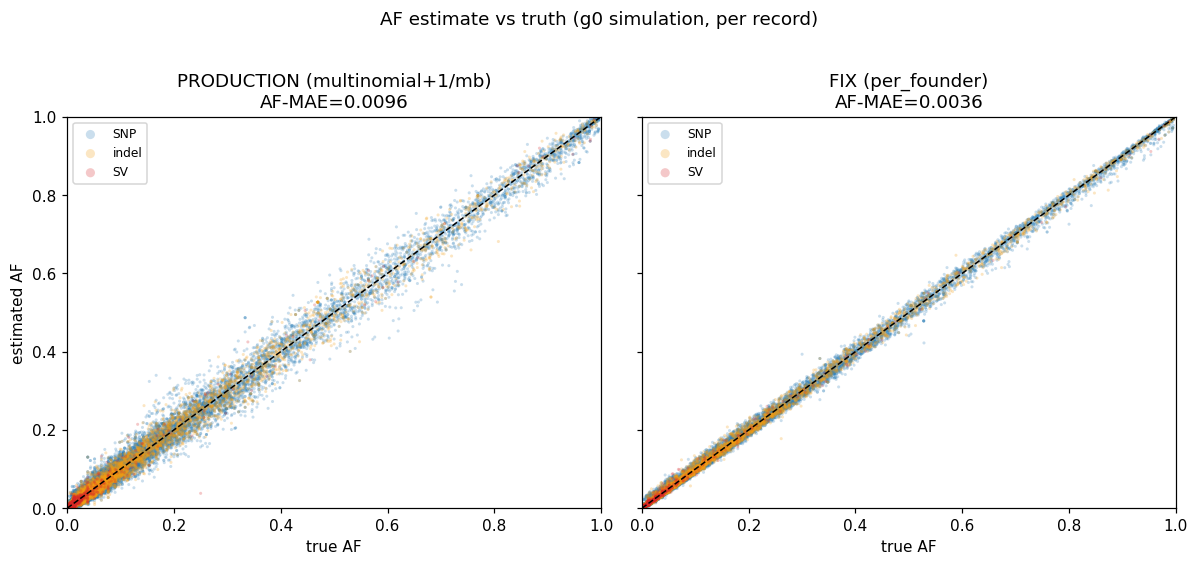

In [4]:
vp=sp.load_npz(f"{ROOT}/panel/arch3/chr1/var_pa_231_arch3_chr1.var_pa.npz").astype(np.float32).tocsr()
vc=sp.load_npz(f"{ROOT}/panel/arch3/chr1/var_pa_231_arch3_chr1.var_called.npz").astype(np.float32).tocsr()
tr=pd.read_csv(f"{ROOT}/benchmarks/p231/sims/cov10_n231_g0_s42_hotspots_p231_chr1/recomb_truth_raw.tsv.gz",sep="\t")
rl=tr['ref_len'].values.astype(int); al=tr['alt_len'].values.astype(int)
vcls=np.where(np.maximum(rl,al)>=50,"SV",np.where((rl==1)&(al==1),"SNP","indel"))
taf=tr['truth_af'].values.astype(float)
def project(h):
    h=h.astype(np.float32); return (h@vp)/np.maximum(h@vc,1e-12)
af_prod=project(h_prod_g0); af_fix=project(h_fix_g0)
def mae(a): m=np.isfinite(a)&np.isfinite(taf); return float(np.mean(np.abs(a[m]-taf[m])))
print("AF-MAE  production=%.4f  fix=%.4f"%(mae(af_prod),mae(af_fix)))

cmap={"SNP":"#2c7fb8","indel":"#f39c12","SV":"#d62728"}
fig,ax=plt.subplots(1,2,figsize=(11,5),sharex=True,sharey=True)
sub=np.random.default_rng(0)
for a,(af,lab) in zip(ax,[(af_prod,"PRODUCTION (multinomial+1/mb)"),(af_fix,"FIX (per_founder)")]):
    m=np.isfinite(af)&np.isfinite(taf); idx=sub.choice(np.flatnonzero(m),min(40000,int(m.sum())),replace=False)
    for cl in ["SNP","indel","SV"]:
        s=idx[vcls[idx]==cl]; a.scatter(taf[s],af[s],s=4,alpha=0.25,color=cmap[cl],edgecolor='none',label=cl,rasterized=True)
    a.plot([0,1],[0,1],'k--',lw=1); a.set_title(f"{lab}\nAF-MAE={mae(af):.4f}")
    a.set_xlabel("true AF"); a.legend(markerscale=3,fontsize=8)
ax[0].set_ylabel("estimated AF"); ax[0].set_xlim(0,1); ax[0].set_ylim(0,1)
fig.suptitle("AF estimate vs truth (g0 simulation, per record)",y=1.02); fig.tight_layout(); plt.show()

## 4. Factorial ablation (per-record AF-MAE) — production is the worst config
16 configs = {4 filters} x {multinomial, poisson} x {omega none, 1/m_b}, real g0 sim reads, sorted best->worst.

,filter,mode,omega,n_abs,h_rmse,AF_MAE,AF_RMSE,AF_outlier
0,FILT2INV,poisson,none,0,0.001721,0.003596,0.006445,0.000014
1,FILT2,poisson,none,0,0.001724,0.003616,0.006495,0.000014
2,NOINV,poisson,none,0,0.002756,0.004445,0.009618,0.000085
3,FILT2,poisson,1/mb,0,0.002178,0.004449,0.008212,0.000042
4,ALL,poisson,none,0,0.002773,0.004452,0.009688,0.000088
5,FILT2INV,poisson,1/mb,0,0.002199,0.004472,0.008236,0.000043
6,ALL,poisson,1/mb,0,0.003996,0.006418,0.013904,0.000536
7,NOINV,poisson,1/mb,0,0.004012,0.006447,0.013943,0.000583
8,FILT2,multinomial,none,34,0.003224,0.008432,0.014441,0.001487
9,FILT2INV,multinomial,none,34,0.003230,0.008436,0.014443,0.001487


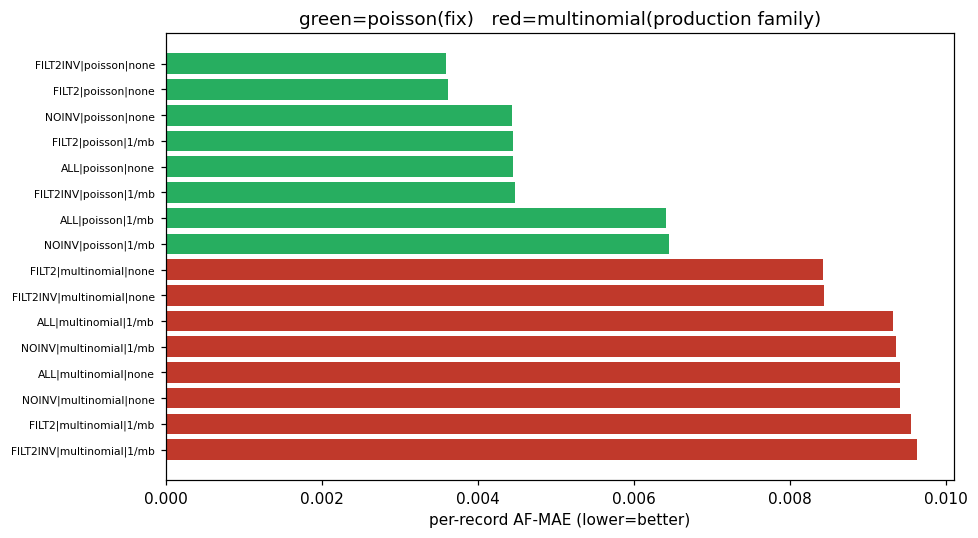

In [5]:
t=pd.read_csv(f"{SV}/fix_ablation/ablation_table.tsv",sep="\t").sort_values("AF_MAE")
disp=t[["filter","mode","omega","n_abs","h_rmse","AF_MAE","AF_RMSE","AF_outlier"]].reset_index(drop=True)
display(disp)
fig,ax=plt.subplots(figsize=(9,5))
names=(disp["filter"]+"|"+disp["mode"]+"|"+disp["omega"]).values
cols=["#27ae60" if m=="poisson" else "#c0392b" for m in disp["mode"]]
ax.barh(range(len(disp)),disp["AF_MAE"],color=cols); ax.set_yticks(range(len(disp))); ax.set_yticklabels(names,fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("per-record AF-MAE (lower=better)")
ax.set_title("green=poisson(fix)   red=multinomial(production family)"); fig.tight_layout(); plt.show()

## 5. Real seed-mix S1 (Chr1) — founders recovered toward hapFIRE
hapFIRE (external ruler) as reference; `h x 231` where 1.0 = equimolar.

n_absorbed prod=40 fix=18 | pearson-vs-hapFIRE prod=0.32 fix=0.44


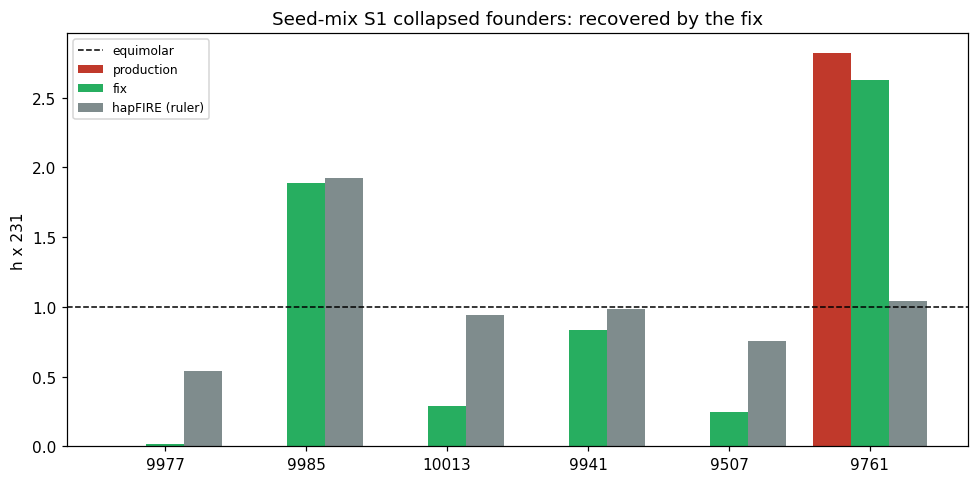

In [6]:
d=np.load(f"{SV}/fix_seedmix/seedmix_fix_h.npz",allow_pickle=True)
sfo=d['founders'].astype(str); hap=d['hap']; hpp=d['h__prod_multinomial']; hff=d['h__fix_poisson']
sm=json.load(open(f"{SV}/fix_seedmix/seedmix_fix_summary.json"))
print("n_absorbed prod=%d fix=%d | pearson-vs-hapFIRE prod=%.2f fix=%.2f"%(
    sm['prod_multinomial']['n_abs_1e3'],sm['fix_poisson']['n_abs_1e3'],
    sm['prod_multinomial']['pearson_vs_hapfire'],sm['fix_poisson']['pearson_vs_hapfire']))
ix=[list(sfo).index(w) for w in WATCH]; x=np.arange(len(WATCH)); w=0.27
fig,ax=plt.subplots(figsize=(9,4.5))
ax.bar(x-w,hpp[ix]*231,w,color="#c0392b",label="production")
ax.bar(x,   hff[ix]*231,w,color="#27ae60",label="fix")
ax.bar(x+w, hap[ix]*231,w,color="#7f8c8d",label="hapFIRE (ruler)")
ax.axhline(1,color='k',ls='--',lw=1,label="equimolar")
ax.set_xticks(x); ax.set_xticklabels(WATCH); ax.set_ylabel("h x 231")
ax.set_title("Seed-mix S1 collapsed founders: recovered by the fix"); ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 6. Real seed-mix — kMate vs hapFIRE, genome-wide & sample-averaged, founders ordered by kMate

kMate h and hapFIRE ecotype frequencies are both **averaged across chromosomes and across all available seed-mix samples** (not just S1/Chr1). Founders sorted by their mean kMate frequency (orange = kMate mean, monotonic; blue = hapFIRE mean at the same founders; dashed = equimolar 1/231). Shaded band = founders kMate calls at <=1e-3 (collapsed). Production keeps a collapsed band on the left (kMate ~0 where hapFIRE sits near 1/231); the fix shrinks it and the orange curve tracks the hapFIRE cloud around 1/231.

kMate & hapFIRE averaged over 6 samples: ['S1', 'S2', 'S3', 'S4', 'S6', 'S8']
hapFIRE founders matched across all samples: 231/231


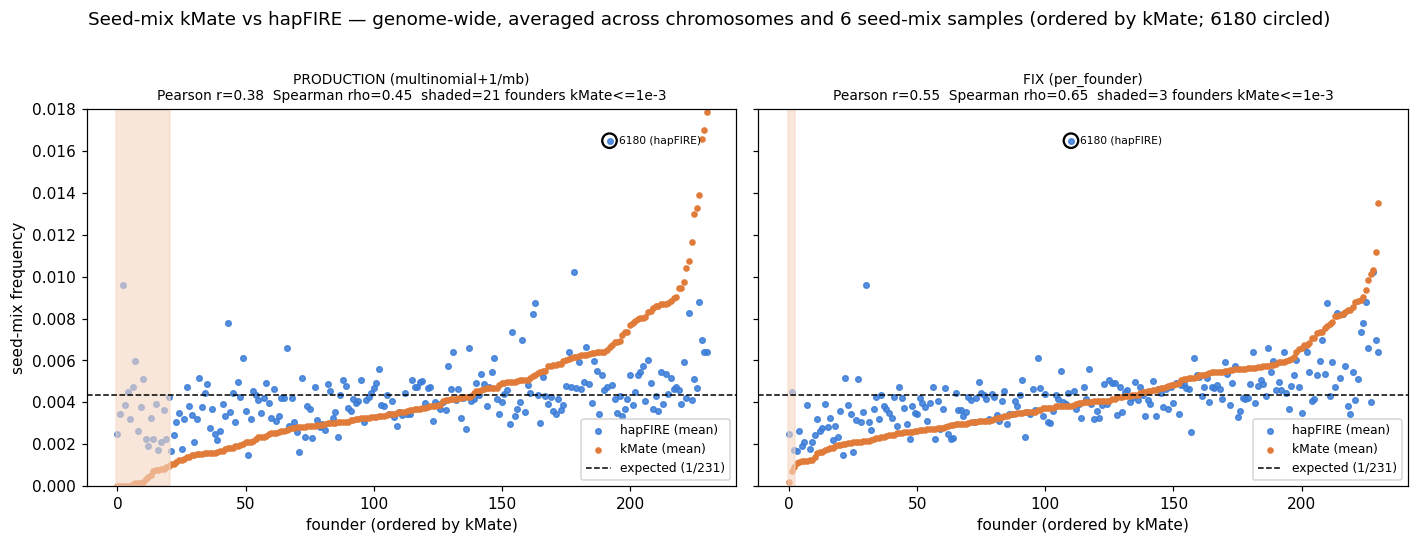

In [7]:
from scipy.stats import spearmanr
HF_DIR="/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix"
gw6=np.load(f"{SV}/fix_seedmix/seedmix_allsamples_h.npz",allow_pickle=True)
sfo=gw6['founders'].astype(str); F=len(sfo)
samples6=sorted({k.split("__")[1] for k in gw6.files if k.startswith("agg_fix__")})
# kMate genome-wide (chrom-averaged) h means over samples, each renormalized to sum 1
hpp=np.vstack([gw6[f"agg_prod__{s}"] for s in samples6]).mean(0); hpp=hpp/hpp.sum()
hff=np.vstack([gw6[f"agg_fix__{s}"]  for s in samples6]).mean(0); hff=hff/hff.sum()
# hapFIRE per-sample ecotype freqs, averaged over the SAME samples, aligned to sfo
hstk=[]
for s in samples6:
    n=s.replace("SEEDMIX_S","")
    m={}
    for line in open(f"{HF_DIR}/s{n}_ecotype_frequency.txt"):
        fid,fr=line.split(); m[fid]=float(fr)
    hstk.append(np.array([m.get(f,np.nan) for f in sfo]))
hstk=np.vstack(hstk); hap=np.nanmean(hstk,0); hap=hap/hap.sum()
N=len(samples6)
print("kMate & hapFIRE averaged over %d samples: %s"%(N,[s.replace('SEEDMIX_','') for s in samples6]))
print("hapFIRE founders matched across all samples: %d/%d"%(int(np.isfinite(hstk).all(0).sum()),F))

J6180=list(sfo).index('6180')
fig,ax=plt.subplots(1,2,figsize=(13,4.8),sharey=True)
for a,(est,lab) in zip(ax,[(hpp,"PRODUCTION (multinomial+1/mb)"),(hff,"FIX (per_founder)")]):
    order=np.argsort(est); x=np.arange(len(est))
    pos=int(np.argsort(np.argsort(est))[J6180])   # x-position of founder 6180
    a.scatter(x,hap[order],s=13,color='#3b7dd8',alpha=0.85,label='hapFIRE (mean)')
    a.scatter(x,est[order],s=11,color='#e07b39',label='kMate (mean)')
    a.axhline(U,color='k',ls='--',lw=1,label='expected (1/231)')
    ncol=int((est<=1e-3).sum())
    if ncol>0: a.axvspan(-0.5,ncol-0.5,color='#f6d6c2',alpha=0.6)
    # highlight founder 6180 (hapFIRE outlier at ~0.016)
    a.scatter([pos],[hap[J6180]],s=90,facecolors='none',edgecolors='k',lw=1.5,zorder=5)
    a.annotate('6180 (hapFIRE)',(pos,hap[J6180]),textcoords='offset points',xytext=(6,-2),fontsize=7)
    r=np.corrcoef(est,hap)[0,1]; rho=spearmanr(est,hap).statistic
    a.set_title(f"{lab}\nPearson r={r:.2f}  Spearman rho={rho:.2f}  shaded={ncol} founders kMate<=1e-3",fontsize=9)
    a.set_ylim(0,0.018); a.set_xlabel("founder (ordered by kMate)")
    a.legend(fontsize=8,loc='lower right')
ax[0].set_ylabel("seed-mix frequency")
fig.suptitle(f"Seed-mix kMate vs hapFIRE — genome-wide, averaged across chromosomes and {N} seed-mix samples (ordered by kMate; 6180 circled)",y=1.02)
fig.tight_layout(); plt.show()

## 7. Genome-wide real seed-mix — all samples, chrom-mean vs 1/231

Global-mode kMate on the real seed-mix replicates, aggregated over 5 chromosomes (the production 'kmate' aggregation). This is the real-data confirmation of the founder-decomposition fix. `absorbed` = founders with aggregate h < 1e-3 (should be 0 for an equimolar mix).

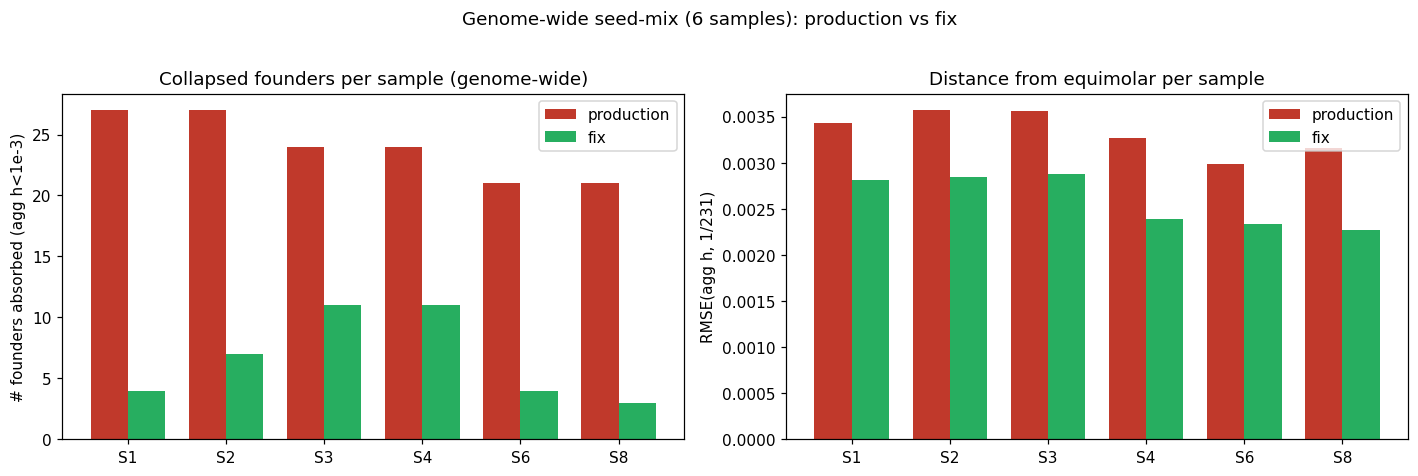

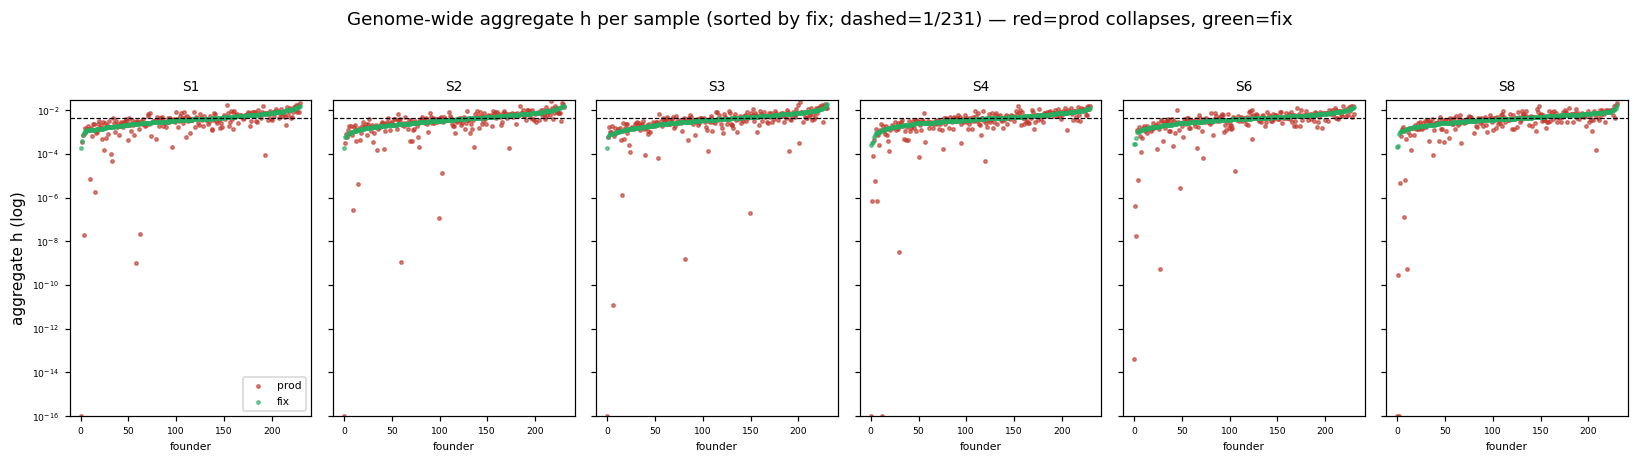

samples: ['SEEDMIX_S1', 'SEEDMIX_S2', 'SEEDMIX_S3', 'SEEDMIX_S4', 'SEEDMIX_S6', 'SEEDMIX_S8']


In [8]:
import os, json
gw = f"{SV}/fix_seedmix/seedmix_allsamples_h.npz"
if not os.path.exists(gw):
    print("genome-wide all-samples run still in progress (job 35546571).")
else:
    d = np.load(gw, allow_pickle=True); sm = json.load(open(f"{SV}/fix_seedmix/seedmix_allsamples_summary.json"))
    fo = d["founders"].astype(str); F = len(fo); u = 1.0/F
    samples = sorted({k.split("__")[1] for k in d.files if k.startswith("agg_fix__")})
    # (a) absorbed founders + RMSE-vs-1/231 per sample
    nap = [sm[f"{s}_prod"]["n_abs"] for s in samples]; naf = [sm[f"{s}_fix"]["n_abs"] for s in samples]
    rp = [sm[f"{s}_prod"]["rmse_vs_uniform"] for s in samples]; rf = [sm[f"{s}_fix"]["rmse_vs_uniform"] for s in samples]
    x = np.arange(len(samples)); w = 0.38
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    ax[0].bar(x-w/2, nap, w, color="#c0392b", label="production"); ax[0].bar(x+w/2, naf, w, color="#27ae60", label="fix")
    ax[0].set_xticks(x); ax[0].set_xticklabels([s.replace("SEEDMIX_","") for s in samples]); ax[0].set_ylabel("# founders absorbed (agg h<1e-3)")
    ax[0].set_title("Collapsed founders per sample (genome-wide)"); ax[0].legend()
    ax[1].bar(x-w/2, rp, w, color="#c0392b", label="production"); ax[1].bar(x+w/2, rf, w, color="#27ae60", label="fix")
    ax[1].set_xticks(x); ax[1].set_xticklabels([s.replace("SEEDMIX_","") for s in samples]); ax[1].set_ylabel("RMSE(agg h, 1/231)")
    ax[1].set_title("Distance from equimolar per sample"); ax[1].legend()
    fig.suptitle(f"Genome-wide seed-mix ({len(samples)} samples): production vs fix", y=1.02); fig.tight_layout(); plt.show()
    # (b) per-sample aggregate h sorted by fix, log-y, 1/231 line
    ns = len(samples); fig, axes = plt.subplots(1, ns, figsize=(2.5*ns, 4), sharey=True)
    if ns == 1: axes = [axes]
    for a, s in zip(axes, samples):
        hp = d[f"agg_prod__{s}"]; hf = d[f"agg_fix__{s}"]; order = np.argsort(hf); xx = np.arange(F)
        a.scatter(xx, np.maximum(hp[order],1e-16), s=5, color="#c0392b", alpha=0.6, label="prod")
        a.scatter(xx, np.maximum(hf[order],1e-16), s=5, color="#27ae60", alpha=0.6, label="fix")
        a.axhline(u, color="k", ls="--", lw=0.8); a.set_yscale("log"); a.set_ylim(1e-16, 0.03)
        a.set_title(s.replace("SEEDMIX_",""), fontsize=9); a.set_xlabel("founder", fontsize=7); a.tick_params(labelsize=6)
    axes[0].set_ylabel("aggregate h (log)"); axes[0].legend(fontsize=7, loc="lower right")
    fig.suptitle("Genome-wide aggregate h per sample (sorted by fix; dashed=1/231) — red=prod collapses, green=fix", y=1.04)
    fig.tight_layout(); plt.show()
    print("samples:", samples)

## Summary
- **Root cause:** global-scalar M-step normalization -> hat_h_f ∝ h_true_f·Kf_w_f (completeness bias).
- **Fix:** per-founder normalization (RSEM effective-length correction); `normalize="per_founder"`, opt-in, default byte-identical.
- **h vs truth:** fix recovers slope ~1.0 (production ~0.6), 0 collapsed founders.
- **AF vs truth:** fix AF-MAE ~2.7x better; production is the worst config in the factorial.
- **h vs truth:** fix recovers slope ~1.0 (production ~0.6), 0 collapsed founders.
- **AF vs truth:** fix AF-MAE ~2.7x better; production is the worst config in the factorial.
- **Real seed-mix (genome-wide, all samples):** fix cuts collapsed founders ~60-85% per sample (e.g. S1 27->4), consistently.
- **DECISION:** per_founder is THE normalization (default everywhere, global + window); multinomial deprecated to legacy flag. Global mode drops omega=1/m_b, keeps filt2inv. Window mode: local-only is the meaningful mode (per_founder wins ~20% RMSE); star2 anchor/smoothing difference was marginal.